<a href="https://colab.research.google.com/github/Adyan213/Hands-On-ML/blob/main/Chapter_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

In [2]:
X=tf.range(10)
dataset=tf.data.Dataset.from_tensor_slices(X)
dataset

<_TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.int32, name=None)>

In [3]:
for item in dataset:
  print(item)

tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor(4, shape=(), dtype=int32)
tf.Tensor(5, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(7, shape=(), dtype=int32)
tf.Tensor(8, shape=(), dtype=int32)
tf.Tensor(9, shape=(), dtype=int32)


In [4]:
X_nested={'a':([1, 2, 3], [4, 5, 6]), 'b':[7, 8, 9]}
dataset=tf.data.Dataset.from_tensor_slices(X_nested)
for item in dataset:
  print(item)

{'a': (<tf.Tensor: shape=(), dtype=int32, numpy=1>, <tf.Tensor: shape=(), dtype=int32, numpy=4>), 'b': <tf.Tensor: shape=(), dtype=int32, numpy=7>}
{'a': (<tf.Tensor: shape=(), dtype=int32, numpy=2>, <tf.Tensor: shape=(), dtype=int32, numpy=5>), 'b': <tf.Tensor: shape=(), dtype=int32, numpy=8>}
{'a': (<tf.Tensor: shape=(), dtype=int32, numpy=3>, <tf.Tensor: shape=(), dtype=int32, numpy=6>), 'b': <tf.Tensor: shape=(), dtype=int32, numpy=9>}


In [5]:
dataset=tf.data.Dataset.from_tensor_slices(tf.range(10))
dataset=dataset.repeat(3).batch(7)
for item in dataset:
  print(item)

tf.Tensor([0 1 2 3 4 5 6], shape=(7,), dtype=int32)
tf.Tensor([7 8 9 0 1 2 3], shape=(7,), dtype=int32)
tf.Tensor([4 5 6 7 8 9 0], shape=(7,), dtype=int32)
tf.Tensor([1 2 3 4 5 6 7], shape=(7,), dtype=int32)
tf.Tensor([8 9], shape=(2,), dtype=int32)


In [6]:
dataset=dataset.map(lambda x: x*2)
for item in dataset:
  print(item)

tf.Tensor([ 0  2  4  6  8 10 12], shape=(7,), dtype=int32)
tf.Tensor([14 16 18  0  2  4  6], shape=(7,), dtype=int32)
tf.Tensor([ 8 10 12 14 16 18  0], shape=(7,), dtype=int32)
tf.Tensor([ 2  4  6  8 10 12 14], shape=(7,), dtype=int32)
tf.Tensor([16 18], shape=(2,), dtype=int32)


In [7]:
dataset=dataset.filter(lambda x: tf.reduce_sum(x)>50)
for item in dataset:
  print(item)

tf.Tensor([14 16 18  0  2  4  6], shape=(7,), dtype=int32)
tf.Tensor([ 8 10 12 14 16 18  0], shape=(7,), dtype=int32)
tf.Tensor([ 2  4  6  8 10 12 14], shape=(7,), dtype=int32)


In [8]:
for item in dataset.take(2):
  print(item)

tf.Tensor([14 16 18  0  2  4  6], shape=(7,), dtype=int32)
tf.Tensor([ 8 10 12 14 16 18  0], shape=(7,), dtype=int32)


In [9]:
dataset=tf.data.Dataset.range(10).repeat(2)
dataset=dataset.shuffle(buffer_size=4, seed=42).batch(7)
for item in dataset:
  print(item)

tf.Tensor([1 4 2 3 5 0 6], shape=(7,), dtype=int64)
tf.Tensor([9 8 2 0 3 1 4], shape=(7,), dtype=int64)
tf.Tensor([5 7 9 6 7 8], shape=(6,), dtype=int64)


In [10]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target.reshape(-1, 1), random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [11]:
import numpy as np
from pathlib import Path

def save_to_csv_files(data, name_prefix, header=None, n_parts=10):
  housing_dir=Path()/'datasets'/'housing'
  housing_dir.mkdir(parents=True, exist_ok=True)
  filename_format='my_{}_{:02d}.csv'

  filepaths=[]
  m=len(data)
  chunks=np.array_split(np.arange(m), n_parts)
  for file_idx, row_indices in enumerate(chunks):
    part_csv=housing_dir/filename_format.format(name_prefix, file_idx)
    filepaths.append(str(part_csv))
    with open(part_csv, 'w') as f:
      if header is not None:
        f.write(header)
        f.write('\n')

      for row_idx in row_indices:
        f.write(','.join([str(col) for col in data[row_idx]]))
        f.write('\n')
  return filepaths

train_data=np.c_[X_train, y_train]
valid_data=np.c_[X_valid, y_valid]
test_data=np.c_[X_test, y_test]
header_cols=housing.feature_names+['MedianHouseValue']
header=','.join(header_cols)

train_filepaths=save_to_csv_files(train_data, 'train', header, n_parts=20)
valid_filepaths=save_to_csv_files(valid_data, 'valid', header, n_parts=10)
test_filepaths=save_to_csv_files(test_data, 'test', header, n_parts=10)

In [12]:
print(''.join(open(train_filepaths[0]).readlines()[:4]))

MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
3.5214,15.0,3.0499445061043287,1.106548279689234,1447.0,1.6059933407325193,37.63,-122.43,1.442
5.3275,5.0,6.490059642147117,0.9910536779324056,3464.0,3.4433399602385686,33.69,-117.39,1.687
3.1,29.0,7.5423728813559325,1.5915254237288134,1328.0,2.2508474576271187,38.44,-122.98,1.621



In [13]:
train_filepaths

['datasets/housing/my_train_00.csv',
 'datasets/housing/my_train_01.csv',
 'datasets/housing/my_train_02.csv',
 'datasets/housing/my_train_03.csv',
 'datasets/housing/my_train_04.csv',
 'datasets/housing/my_train_05.csv',
 'datasets/housing/my_train_06.csv',
 'datasets/housing/my_train_07.csv',
 'datasets/housing/my_train_08.csv',
 'datasets/housing/my_train_09.csv',
 'datasets/housing/my_train_10.csv',
 'datasets/housing/my_train_11.csv',
 'datasets/housing/my_train_12.csv',
 'datasets/housing/my_train_13.csv',
 'datasets/housing/my_train_14.csv',
 'datasets/housing/my_train_15.csv',
 'datasets/housing/my_train_16.csv',
 'datasets/housing/my_train_17.csv',
 'datasets/housing/my_train_18.csv',
 'datasets/housing/my_train_19.csv']

In [14]:
filepath_dataset = tf.data.Dataset.list_files(train_filepaths, seed=42)

In [15]:
for filepath in filepath_dataset:
  print(filepath)

tf.Tensor(b'datasets/housing/my_train_05.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_16.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_01.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_17.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_00.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_14.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_10.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_02.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_12.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_19.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_07.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_09.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_13.csv', shape=(), dtype=string)
tf.Tensor(b'datasets/housing/my_train_15.csv', shape=(), dtype=string)
tf.Ten

In [16]:
n_readers=5
dataset=filepath_dataset.interleave(
    lambda filepath: tf.data.TextLineDataset(filepath).skip(1),
    cycle_length=n_readers
)

In [17]:
for line in dataset.take(5):
  print(line)

tf.Tensor(b'4.5909,16.0,5.475877192982456,1.0964912280701755,1357.0,2.9758771929824563,33.63,-117.71,2.418', shape=(), dtype=string)
tf.Tensor(b'2.4792,24.0,3.4547038327526134,1.1341463414634145,2251.0,3.921602787456446,34.18,-118.38,2.0', shape=(), dtype=string)
tf.Tensor(b'4.2708,45.0,5.121387283236994,0.953757225433526,492.0,2.8439306358381504,37.48,-122.19,2.67', shape=(), dtype=string)
tf.Tensor(b'2.1856,41.0,3.7189873417721517,1.0658227848101265,803.0,2.0329113924050635,32.76,-117.12,1.205', shape=(), dtype=string)
tf.Tensor(b'4.1812,52.0,5.701388888888889,0.9965277777777778,692.0,2.4027777777777777,33.73,-118.31,3.215', shape=(), dtype=string)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [19]:
X_mean, X_std=scaler.mean_, scaler.scale_
n_inputs=8

def parse_csv_line(line):
  defs=[0.]*n_inputs+[tf.constant([], dtype=tf.float32)]
  fields=tf.io.decode_csv(line, record_defaults=defs)
  return tf.stack(fields[:-1]), tf.stack(fields[-1:])

def preprocess(line):
  X, y=parse_csv_line(line)
  return (X-X_mean)/X_std, y

In [20]:
preprocess(b'4.2083, 44.0, 5.3232, 0.9171, 846.0, 2.3370, 37.47, -122.2, 2.782')

(<tf.Tensor: shape=(8,), dtype=float32, numpy=
 array([ 0.16579159,  1.216324  , -0.05204564, -0.39215982, -0.5277444 ,
        -0.2633488 ,  0.8543046 , -1.3072058 ], dtype=float32)>,
 <tf.Tensor: shape=(1,), dtype=float32, numpy=array([2.782], dtype=float32)>)

In [21]:
def csv_reader_dataset(filepaths, n_readers=5, n_read_threads=None,
                       n_parse_threads=5, shuffle_buffer_size=10_000, seed=42,
                       batch_size=32):
  dataset=tf.data.Dataset.list_files(filepath, seed=seed)
  dataset=dataset.interleave(
      lambda filepath: tf.data.TextLineDataset(filepath).skip(1),
      cycle_length=n_readers, num_parallel_calls=n_read_threads
  )
  dataset=dataset.map(preprocess, num_parallel_calls=n_parse_threads)
  dataset=dataset.shuffle(shuffle_buffer_size, seed=seed)
  return dataset.batch(batch_size).prefetch(1)

In [22]:
train_set=csv_reader_dataset(train_filepaths)
valid_set=csv_reader_dataset(valid_filepaths)
test_set=csv_reader_dataset(test_filepaths)

In [23]:
tf.keras.backend.clear_session()
np.random.seed(42)

In [24]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Dense(30, activation='relu', kernel_initializer='he_normal',
                          input_shape=X_train.shape[1:]),
    tf.keras.layers.Dense(1)
])
model.compile(loss='mse', optimizer='sgd')
model.fit(train_set, epochs=10, validation_data=valid_set)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


     11/Unknown 1s 5ms/step - loss: 2.8444  

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 1.8401 - val_loss: 1.2535
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 1.2139 - val_loss: 1.0504
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0244 - val_loss: 1.0372
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.9685 - val_loss: 0.9194
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.8941 - val_loss: 0.8724
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8471 - val_loss: 0.8293
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8069 - val_loss: 0.7759
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7770 - val_loss: 0.7430
Epoch 9/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7398 - val_loss: 0.7453
Epoch 10/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7222 - val_loss: 0.6972


In [25]:
test_mse=model.evaluate(test_set)
new_set=test_set.take(3)
y_pred=model.predict(new_set)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6972
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [26]:
y_pred

array([[1.1602829 ],
       [3.7886937 ],
       [1.7008014 ],
       [2.3124187 ],
       [1.3655813 ],
       [1.2313583 ],
       [1.1030614 ],
       [2.0931187 ],
       [1.0377271 ],
       [0.6096945 ],
       [1.6183445 ],
       [1.5723636 ],
       [1.1522315 ],
       [2.6008806 ],
       [1.4886789 ],
       [1.2639248 ],
       [1.5367801 ],
       [1.3802371 ],
       [1.5533013 ],
       [1.1049981 ],
       [1.7142875 ],
       [1.3384385 ],
       [2.640934  ],
       [6.895198  ],
       [1.4795835 ],
       [0.03397295],
       [1.9118705 ],
       [2.0263038 ],
       [0.53336644],
       [1.5287962 ],
       [1.7329955 ],
       [1.3012254 ],
       [4.8617883 ],
       [2.3769913 ],
       [1.6505728 ],
       [2.0981057 ],
       [1.5895648 ],
       [2.0242069 ],
       [1.7213492 ],
       [0.6180034 ],
       [3.1103032 ],
       [1.5134854 ],
       [2.586856  ],
       [2.7161734 ],
       [2.0793796 ],
       [1.8628366 ],
       [2.692951  ],
       [0.985

In [28]:
tf.random.set_seed(42)
norm_layer=tf.keras.layers.Normalization()
model=tf.keras.models.Sequential([
    norm_layer,
    tf.keras.layers.Dense(1)
])
model.compile(loss='mse', optimizer=tf.keras.optimizers.SGD(learning_rate=2e-3))
norm_layer.adapt(X_train)
model.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=5)

Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.8417 - val_loss: 1.8639
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7191 - val_loss: 0.6214
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6027 - val_loss: 0.6734
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5845 - val_loss: 0.6581
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.5743 - val_loss: 0.6495


In [29]:
norm_layer=tf.keras.layers.Normalization()
norm_layer.adapt(X_train)
X_train_scaled=norm_layer(X_train)
X_valid_scaled=norm_layer(X_valid)

In [30]:
tf.random.set_seed(42)
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1)])
model.compile(loss="mse", optimizer=tf.keras.optimizers.SGD(learning_rate=2e-3))
model.fit(X_train_scaled, y_train, epochs=5,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3.0789 - val_loss: 1.6713
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7577 - val_loss: 0.6445
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6130 - val_loss: 0.6749
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.5911 - val_loss: 0.6590
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5791 - val_loss: 0.6488


In [31]:
final_model=tf.keras.Sequential([
    norm_layer,
    model
])
X_new=X_test[:3]
y_pred=final_model(X_new)

In [32]:
y_pred

<tf.Tensor: shape=(3, 1), dtype=float32, numpy=
array([[0.8389884],
       [1.6996095],
       [2.3618536]], dtype=float32)>

In [33]:
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(5)

In [34]:
dataset=dataset.map(lambda X, y : (norm_layer(X), y))

In [35]:
list(dataset.take(1))

[(<tf.Tensor: shape=(5, 8), dtype=float32, numpy=
  array([[-0.19397889, -1.0778131 , -0.9433854 ,  0.01485314,  0.02073333,
          -0.57291627,  0.9292612 , -1.4221537 ],
         [ 0.7519831 , -1.868895  ,  0.40547806, -0.23327684,  1.8614649 ,
           0.20516537, -0.9165477 ,  1.0966716 ],
         [-0.41469118,  0.02970133,  0.8180882 ,  1.0567837 , -0.0878671 ,
          -0.2998328 ,  1.3087282 , -1.697027  ],
         [ 1.7188957 , -1.3151377 ,  0.32664376, -0.2195511 , -0.33792186,
          -0.11146631, -0.9821345 ,  0.94174504],
         [-0.9620722 , -1.2360295 , -0.05625783, -0.03124396,  1.7090592 ,
          -0.30256987, -0.80411196,  1.3265638 ]], dtype=float32)>,
  <tf.Tensor: shape=(5, 1), dtype=float64, numpy=
  array([[1.442],
         [1.687],
         [1.621],
         [2.621],
         [0.956]])>)]

In [36]:
class MyNormalizationLayer(tf.keras.layers.Layer):
  def adapt(self, X):
    self.mean_=np.mean(X, axis=0, keepdims=True)
    self.std_=np.std(X, axis=0, keepdims=True)

  def call(self, X):
    eps=tf.keras.backend.epsilon()
    return (X-self.mean_)/(self.std_+eps)

In [37]:
my_norm_layer=MyNormalizationLayer()
my_norm_layer.adapt(X_train)
X_train_scaled=my_norm_layer(X_train)
X_valid_scaled=my_norm_layer(X_valid)

In [38]:
tf.random.set_seed(42)
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1)])
model.compile(loss="mse", optimizer=tf.keras.optimizers.SGD(learning_rate=2e-3))
model.fit(X_train_scaled, y_train, epochs=5,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.7438 - val_loss: 0.8586
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6924 - val_loss: 0.7300
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5860 - val_loss: 0.6562
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5709 - val_loss: 0.6471
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5631 - val_loss: 0.6352


In [39]:
age=tf.constant([[10.], [93.], [57.], [18.], [37.], [5.]])
discretize_layer=tf.keras.layers.Discretization(bin_boundaries=[18., 50])
age_categories=discretize_layer(age)
age_categories

<tf.Tensor: shape=(6, 1), dtype=int32, numpy=
array([[0],
       [2],
       [2],
       [1],
       [1],
       [0]], dtype=int32)>

In [40]:
discretize_layer = tf.keras.layers.Discretization(num_bins=3)
discretize_layer.adapt(age)
age_categories = discretize_layer(age)
age_categories

<tf.Tensor: shape=(6, 1), dtype=int32, numpy=
array([[1],
       [2],
       [2],
       [1],
       [2],
       [0]], dtype=int32)>

In [42]:
onehot_layer=tf.keras.layers.CategoryEncoding(num_tokens=3)
onehot_layer(age_categories)

<tf.Tensor: shape=(6, 3), dtype=float32, numpy=
array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]], dtype=float32)>

In [43]:
two_age_categories=np.array([[1, 0], [2, 2], [2, 0]])
onehot_layer(two_age_categories)

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 0.],
       [0., 0., 1.],
       [1., 0., 1.]], dtype=float32)>

In [44]:
onehot_layer = tf.keras.layers.CategoryEncoding(num_tokens=3, output_mode="count")
onehot_layer(two_age_categories)

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 0.],
       [0., 0., 2.],
       [1., 0., 1.]], dtype=float32)>

In [45]:
onehot_layer=tf.keras.layers.CategoryEncoding(num_tokens=3+3)
onehot_layer(two_age_categories+[0, 3])

<tf.Tensor: shape=(3, 6), dtype=float32, numpy=
array([[0., 1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 1.],
       [0., 0., 1., 1., 0., 0.]], dtype=float32)>

In [46]:
# extra code – shows another way to one-hot encode each feature separately
onehot_layer = tf.keras.layers.CategoryEncoding(num_tokens=3,
                                                output_mode="one_hot")
tf.keras.layers.concatenate([onehot_layer(cat)
                             for cat in tf.transpose(two_age_categories)])

<tf.Tensor: shape=(3, 6), dtype=float32, numpy=
array([[0., 1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 1.],
       [0., 0., 1., 1., 0., 0.]], dtype=float32)>

In [47]:
# extra code – shows another way to do this, using tf.one_hot() and Flatten
tf.keras.layers.Flatten()(tf.one_hot(two_age_categories, depth=3))

<tf.Tensor: shape=(3, 6), dtype=float32, numpy=
array([[0., 1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 1.],
       [0., 0., 1., 1., 0., 0.]], dtype=float32)>

In [48]:
cities=["Auckland", "Paris", "Paris", "San Francisco"]
str_lookup_layer=tf.keras.layers.StringLookup()
str_lookup_layer.adapt(cities)
str_lookup_layer([["Paris"], ["Auckland"], ["Auckland"], ["Montreal"]])

<tf.Tensor: shape=(4, 1), dtype=int64, numpy=
array([[1],
       [3],
       [3],
       [0]])>

In [49]:
str_lookup_layer = tf.keras.layers.StringLookup(output_mode="one_hot")
str_lookup_layer.adapt(cities)
str_lookup_layer([["Paris"], ["Auckland"], ["Auckland"], ["Montreal"]])

<tf.Tensor: shape=(4, 4), dtype=int64, numpy=
array([[0, 1, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 0, 1],
       [1, 0, 0, 0]])>

In [50]:
str_lookup_layer = tf.keras.layers.StringLookup(num_oov_indices=5)
str_lookup_layer.adapt(cities)
str_lookup_layer([["Paris"], ["Auckland"], ["Foo"], ["Bar"], ["Baz"]])

<tf.Tensor: shape=(5, 1), dtype=int64, numpy=
array([[5],
       [7],
       [4],
       [3],
       [4]])>

In [51]:
hashing_layer = tf.keras.layers.Hashing(num_bins=10)
hashing_layer([["Paris"], ["Tokyo"], ["Auckland"], ["Montreal"]])

<tf.Tensor: shape=(4, 1), dtype=int64, numpy=
array([[0],
       [1],
       [9],
       [1]])>

In [52]:
tf.random.set_seed(42)
embedding_layer=tf.keras.layers.Embedding(input_dim=5, output_dim=2)
embedding_layer(np.array([2, 4, 2]))

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[0.01310394, 0.00782503],
       [0.03031382, 0.00362432],
       [0.01310394, 0.00782503]], dtype=float32)>

In [53]:
tf.random.set_seed(42)
ocean_prox = ["<1H OCEAN", "INLAND", "NEAR OCEAN", "NEAR BAY", "ISLAND"]
str_lookup_layer=tf.keras.layers.StringLookup()
str_lookup_layer.adapt(ocean_prox)
lookup_and_embed=tf.keras.Sequential([
    str_lookup_layer,
    tf.keras.layers.Embedding(input_dim=str_lookup_layer.vocabulary_size(),
                              output_dim=2)
])
lookup_and_embed(np.array(["<1H OCEAN", "ISLAND", "<1H OCEAN"]))

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[-0.00223132, -0.03664058],
       [ 0.02308014, -0.00413262],
       [-0.00223132, -0.03664058]], dtype=float32)>

In [54]:
tf.random.set_seed(42)
np.random.seed(42)
X_train_num = np.random.rand(10_000, 8)
X_train_cat = np.random.choice(ocean_prox, size=10_000).astype(object)
y_train = np.random.rand(10_000, 1)
X_valid_num = np.random.rand(2_000, 8)
X_valid_cat = np.random.choice(ocean_prox, size=2_000).astype(object)
y_valid = np.random.rand(2_000, 1)

num_input = tf.keras.layers.Input(shape=[8], name="num")
cat_input = tf.keras.layers.Input(shape=[], dtype=tf.string, name="cat")
cat_embeddings = lookup_and_embed(cat_input)
encoded_inputs = tf.keras.layers.concatenate([num_input, cat_embeddings])
outputs = tf.keras.layers.Dense(1)(encoded_inputs)
model = tf.keras.models.Model(inputs=[num_input, cat_input], outputs=[outputs])
model.compile(loss="mse", optimizer="sgd")
history = model.fit((X_train_num, X_train_cat), y_train, epochs=5,
                    validation_data=((X_valid_num, X_valid_cat), y_valid))

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1620 - val_loss: 0.1219
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1059 - val_loss: 0.0973
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0912 - val_loss: 0.0886
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0860 - val_loss: 0.0853
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0841 - val_loss: 0.0841


In [55]:
train_set = tf.data.Dataset.from_tensor_slices(
    ((X_train_num, X_train_cat), y_train)).batch(32)
valid_set = tf.data.Dataset.from_tensor_slices(
    ((X_valid_num, X_valid_cat), y_valid)).batch(32)
history = model.fit(train_set, epochs=5,
                    validation_data=valid_set)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0834 - val_loss: 0.0836
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0831 - val_loss: 0.0833
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0830 - val_loss: 0.0832
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0829 - val_loss: 0.0831
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0829 - val_loss: 0.0830


In [56]:
train_data = ["To be", "!(to be)", "That's the question", "Be, be, be."]
text_vector_layer=tf.keras.layers.TextVectorization()
text_vector_layer.adapt(train_data)
text_vector_layer(["Be good!", "Question: be or be?"])

<tf.Tensor: shape=(2, 4), dtype=int64, numpy=
array([[2, 1, 0, 0],
       [6, 2, 1, 2]])>

In [57]:
text_vec_layer = tf.keras.layers.TextVectorization(ragged=True)
text_vec_layer.adapt(train_data)
text_vec_layer(["Be good!", "Question: be or be?"])

<tf.RaggedTensor [[2, 1], [6, 2, 1, 2]]>

In [58]:
text_vector_layer=tf.keras.layers.TextVectorization(output_mode='tf_idf')
text_vector_layer.adapt(train_data)
text_vector_layer(["Be good!", "Question: be or be?"])

<tf.Tensor: shape=(2, 6), dtype=float32, numpy=
array([[0.96725637, 0.6931472 , 0.        , 0.        , 0.        ,
        0.        ],
       [0.96725637, 1.3862944 , 0.        , 0.        , 0.        ,
        1.0986123 ]], dtype=float32)>

In [60]:
2 * np.log(1 + 4 / (1 + 3)) #be

np.float64(1.3862943611198906)

In [61]:
1 * np.log(1 + 4 / (1 + 1)) #question

np.float64(1.0986122886681098)

In [62]:
import tensorflow_hub as hub

hub_layer=hub_layer=hub.KerasLayer('https://tfhub.dev/google/nnlm-en-dim50/2')

In [63]:
sentence_embeddings=hub_layer(tf.constant(["To be", "Not to be"]))

In [67]:
sentence_embeddings.numpy().round(2)

array([[-0.25,  0.28,  0.01,  0.1 ,  0.14,  0.16,  0.25,  0.02,  0.07,
         0.13, -0.19,  0.06, -0.04, -0.07,  0.  , -0.08, -0.14, -0.16,
         0.02, -0.24,  0.16, -0.16, -0.03,  0.03, -0.14,  0.03, -0.09,
        -0.04, -0.14, -0.19,  0.07,  0.15,  0.18, -0.23, -0.07, -0.08,
         0.01, -0.01,  0.09,  0.14, -0.03,  0.03,  0.08,  0.1 , -0.01,
        -0.03, -0.07, -0.1 ,  0.05,  0.31],
       [-0.2 ,  0.2 , -0.08,  0.02,  0.19,  0.05,  0.22, -0.09,  0.02,
         0.19, -0.02, -0.14, -0.2 , -0.04,  0.01, -0.07, -0.22, -0.1 ,
         0.16, -0.44,  0.31, -0.1 ,  0.23,  0.15, -0.05,  0.15, -0.13,
        -0.04, -0.08, -0.16, -0.1 ,  0.13,  0.13, -0.18, -0.04,  0.03,
        -0.1 , -0.07,  0.07,  0.03, -0.08,  0.02,  0.05,  0.07, -0.14,
        -0.1 , -0.18, -0.13, -0.04,  0.15]], dtype=float32)

In [68]:
from sklearn.datasets import load_sample_images

images=load_sample_images()['images']
crop_image_layer=tf.keras.layers.CenterCrop(height=100, width=200)
cropped_images=crop_image_layer(images)

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

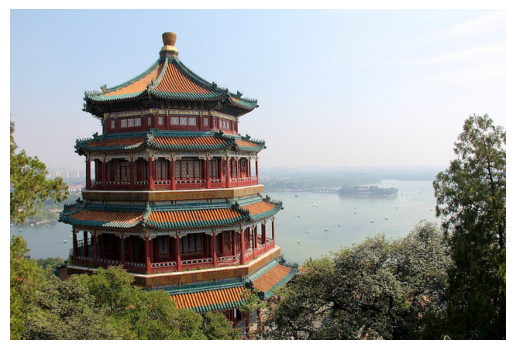

In [69]:
import matplotlib.pyplot as plt

plt.imshow(images[0])
plt.axis('off')

(np.float64(-0.5), np.float64(199.5), np.float64(99.5), np.float64(-0.5))

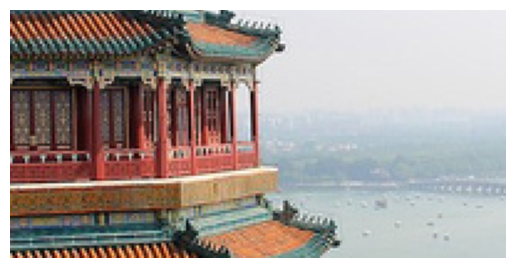

In [71]:
plt.imshow(cropped_images[0]/255)
plt.axis('off')

In [72]:
import tensorflow_datasets as tfds

datasets=tfds.load(name='mnist')
mnist_train, mnist_test=datasets['train'], datasets['test']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.BLSERK_3.0.1/mnist-train.tfrecord-[0-9][0-9][0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.BLSERK_3.0.1/mnist-test.tfrecord-[0-9][0-9][0-9][0-9][0-9…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [73]:
for batch in mnist_train.shuffle(10_000, seed=42).batch(32).prefetch(1):
  images=batch['image']
  labels=batch['label']

In [75]:
train_set, valid_set, test_set = tfds.load(
    name="mnist",
    split=["train[:90%]", "train[90%:]", "test"],
    as_supervised=True,
)
train_set = train_set.shuffle(10_000, seed=42).batch(32).prefetch(1)
valid_set = valid_set.batch(32).cache()
test_set = test_set.batch(32).cache()
tf.random.set_seed(42)

model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='nadam',
              metrics=['accuracy'])
model.fit(train_set, epochs=5, validation_data=valid_set)
test_loss, test_accuracy=model.evaluate(test_set)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8365 - loss: 9.9709 - val_accuracy: 0.8718 - val_loss: 6.3782
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8775 - loss: 5.7675 - val_accuracy: 0.8862 - val_loss: 5.2426
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8818 - loss: 5.3084 - val_accuracy: 0.8792 - val_loss: 5.6059
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8864 - loss: 5.0892 - val_accuracy: 0.8922 - val_loss: 5.2684
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8871 - loss: 4.9443 - val_accuracy: 0.8778 - val_loss: 5.9369
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8818 - loss: 5.5756
